# Step 1: Schoof's steady states and the hysteresis loop

Can a marine ice sheet on this bed have more than one steady grounding-line position for the same ice softness, and are some of those positions unstable? Before writing any time-dependent model, I answer this with Schoof's (2007) grounding-line flux formula and a graphical method: a steady state is where the snowfall upstream of the grounding line equals the ice flux across it. It is the same idea I used for Stommel's box model in project 14.

The setup is MISMIP experiment 3 (Pattyn et al. 2012). The model functions live in `flowline.py`, in this folder.

I load the libraries and the functions from `flowline.py`, and set the parameters of this notebook. The physical constants (densities, gravity, n, m, C, accumulation) are defined once in `flowline.py`, so I print them here to show the values in use. The code works in metres and years.

In [1]:
%matplotlib inline

import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from flowline import (SECONDS_PER_YEAR, RHO_I, RHO_W, G, N_GLEN, M_SLIDE, C_SI, C_YR, ACCUMULATION,
                      a_per_year, bed, bed_slope, flotation_thickness, schoof_prefactor, schoof_exponent,
                      schoof_flux, schoof_flux_slope, steady_a_for_position, schoof_steady_positions)

# Parameters of this notebook
A_TABLE_SI = [3e-25, 2.5e-25, 2e-25, 1.5e-25, 1e-25, 5e-26, 2.5e-26,        # MISMIP EXP 3a, Table 5: A going down
              5e-26, 1e-25, 1.5e-25, 2e-25, 2.5e-25, 3e-25]                 # ... and back up (Pa^-3 s^-1)
A_EXAMPLE_SI = 1e-25        # A for the flux-crossing plot (Pa^-3 s^-1), one of the MISMIP values
X_MAX = 1800e3              # furthest grounding-line position I search (m)
X_PLOT = 1600e3             # right edge of the bed plot (m); the bed drops steeply beyond it
DX_SEARCH = 100.0           # spacing of the search grid for steady states (m)
FIG_DIR = "../figures"
DATA_DIR = "../data"

print(f"rho_i = {RHO_I} kg/m^3, rho_w = {RHO_W} kg/m^3, g = {G} m/s^2, n = {N_GLEN}, m = {M_SLIDE:.4f}")
print(f"C = {C_SI:.4e} Pa m^(-1/3) s^(1/3) = {C_YR:.4e} Pa m^(-1/3) yr^(1/3) | a = {ACCUMULATION} m/yr | "
      f"1 yr = {SECONDS_PER_YEAR:.0f} s")

rho_i = 900.0 kg/m^3, rho_w = 1000.0 kg/m^3, g = 9.8 m/s^2, n = 3.0, m = 0.3333
C = 7.6240e+06 Pa m^(-1/3) s^(1/3) = 2.4126e+04 Pa m^(-1/3) yr^(1/3) | a = 0.3 m/yr | 1 yr = 31556926 s


A check of my unit conversion. Schoof's formula must give the same flux whether I use seconds or years: the flux in m^2/yr must equal the flux in m^2/s times the seconds in a year. I test this at one grounding-line position.

In [2]:
x_test = 1000e3
h_test = flotation_thickness(x_test)
q_si = schoof_prefactor(A_EXAMPLE_SI, C_SI) * h_test ** schoof_exponent()           # m^2/s
q_yr = schoof_flux(x_test, a_per_year(A_EXAMPLE_SI))                                # m^2/yr
print(f"A = {A_EXAMPLE_SI:.1e} Pa^-3 s^-1 = {a_per_year(A_EXAMPLE_SI):.4e} Pa^-3 yr^-1")
print(f"at x = {x_test / 1e3:.0f} km: q (seconds) x seconds per year = {q_si * SECONDS_PER_YEAR:.6e} m^2/yr, "
      f"q (years) = {q_yr:.6e} m^2/yr, relative difference {abs(q_yr / (q_si * SECONDS_PER_YEAR) - 1):.1e}")

A = 1.0e-25 Pa^-3 s^-1 = 3.1557e-18 Pa^-3 yr^-1
at x = 1000 km: q (seconds) x seconds per year = 4.834095e+05 m^2/yr, q (years) = 4.834095e+05 m^2/yr, relative difference 1.1e-16


## The bed and the flotation thickness

The bed is a polynomial that rises above sea level near the divide, deepens toward the ocean, and then has a section where it gets deeper INLAND (the slope is upward toward the ocean): an overdeepening. I find where the bed crosses sea level and where its slope changes sign.

The flotation thickness is the thickness at which ice just floats: a column of ice of thickness H weighs as much as the seawater it pushes aside when rho_i H = rho_w (depth of the bed below sea level). Thinner ice floats, thicker ice rests on the bed.

bed crosses sea level at 478.7 km
bed slope is zero at 973.7 km (b = -748.9 m) and 1265.7 km (b = -629.7 m)
between them the bed rises toward the ocean by 119.2 m


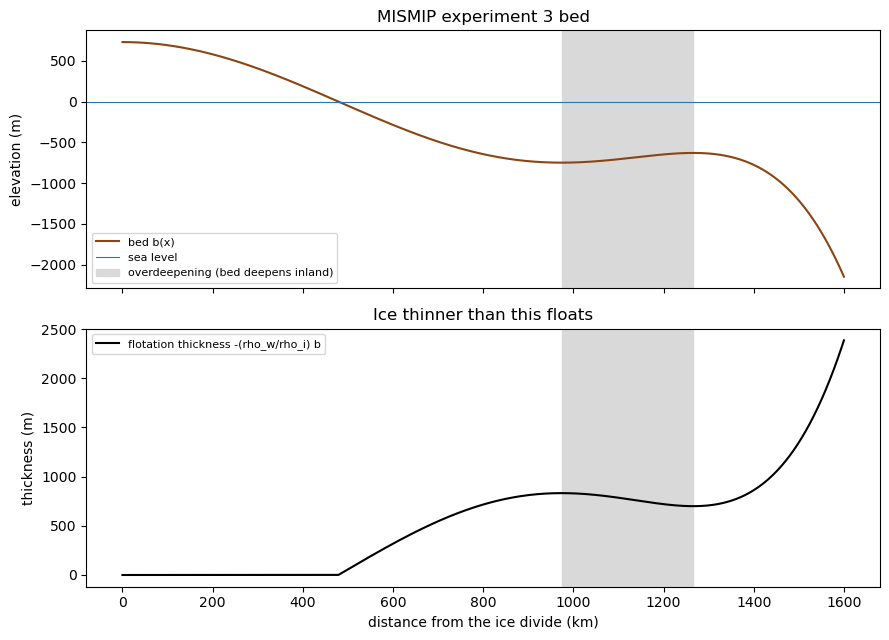

In [3]:
x_sea = brentq(bed, 1e3, 1000e3)                         # where b = 0
x_od1 = brentq(bed_slope, 800e3, 1100e3)                 # slope changes sign: start of the overdeepening
x_od2 = brentq(bed_slope, 1100e3, 1400e3)                # slope changes sign again: end of the overdeepening
print(f"bed crosses sea level at {x_sea / 1e3:.1f} km")
print(f"bed slope is zero at {x_od1 / 1e3:.1f} km (b = {bed(x_od1):.1f} m) and {x_od2 / 1e3:.1f} km (b = {bed(x_od2):.1f} m)")
print(f"between them the bed rises toward the ocean by {bed(x_od2) - bed(x_od1):.1f} m")

x = np.linspace(0.0, X_PLOT, 1601)
fig, axes = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True)
axes[0].plot(x / 1e3, bed(x), color="saddlebrown", label="bed b(x)")
axes[0].axhline(0.0, color="tab:blue", lw=0.8, label="sea level")
axes[0].axvspan(x_od1 / 1e3, x_od2 / 1e3, color="0.85", label="overdeepening (bed deepens inland)")
axes[0].set_ylabel("elevation (m)")
axes[0].set_title("MISMIP experiment 3 bed")
axes[0].legend(fontsize=8)
axes[1].plot(x / 1e3, flotation_thickness(x), color="k", label="flotation thickness -(rho_w/rho_i) b")
axes[1].axvspan(x_od1 / 1e3, x_od2 / 1e3, color="0.85")
axes[1].set_xlabel("distance from the ice divide (km)")
axes[1].set_ylabel("thickness (m)")
axes[1].set_title("Ice thinner than this floats")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "01_bed_and_flotation.png"), dpi=150)
plt.show()

## Schoof's grounding-line flux

Schoof (2007) found that, for a sheet that slides on its bed and an ice shelf that is free to spread into the ocean, the ice flux across the grounding line is set by the ice thickness there:

q(x_g) = K h(x_g)^((m+n+3)/(m+1)),   K = [A (rho_i g)^(n+1) (1 - rho_i/rho_w)^n / (4^n C)]^(1/(m+1))

In plain words: at the grounding line the ice is exactly at flotation, so its thickness h is fixed by the water depth. The floating shelf beyond it is pulled apart by the difference between the ice pressure and the water pressure, and that pull grows with h. Just upstream, in a short boundary layer, the ice must slow down from shelf-like stretching to sliding against the bed. Matching the two gives a flux that grows steeply with h: softer ice (larger A) stretches faster, and stronger basal friction (larger C) holds it back. For n = 3 and m = 1/3 the exponent is (1/3 + 3 + 3)/(4/3):

In [4]:
print(f"exponent (m + n + 3) / (m + 1) = {schoof_exponent():.4f}")
print(f"K for A = {A_EXAMPLE_SI:.0e} Pa^-3 s^-1: {schoof_prefactor(a_per_year(A_EXAMPLE_SI), C_YR):.4e} m^(-2.75) yr^-1")

exponent (m + n + 3) / (m + 1) = 4.7500
K for A = 1e-25 Pa^-3 s^-1: 6.5952e-09 m^(-2.75) yr^-1


## Steady states for one A: snowfall against outflow

All the snow that falls between the divide and the grounding line, a x_g per metre of width, has to leave across the grounding line. So a steady state needs a x_g = q(x_g). I plot both against x_g for A = 1e-25 Pa^-3 s^-1 and find every crossing with a sign-change search followed by `brentq`.

Stability: if the grounding line moves a little seaward, does it come back? Moving seaward adds a little snowfall (a per metre) and changes the outflow by dq/dx_g per metre. If the outflow grows faster than the snowfall (dq/dx_g > a), the ice sheet loses mass and the grounding line retreats back: stable. If not, it keeps going: unstable.

x_g =   799.8 km | b =  -644.4 m | dq/dx_g =  2.147 m/yr vs a = 0.3 m/yr -> stable
x_g =  1124.3 km | b =  -692.3 m | dq/dx_g = -1.421 m/yr vs a = 0.3 m/yr -> unstable
x_g =  1376.3 km | b =  -722.4 m | dq/dx_g =  5.285 m/yr vs a = 0.3 m/yr -> stable


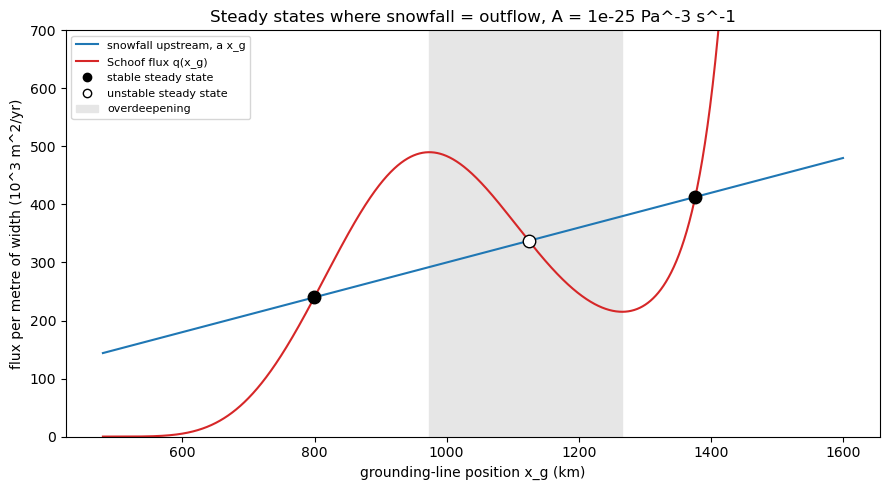

In [5]:
def steady_positions(a_yr):
    # all grounding-line positions (m) where a x_g = q(x_g), between the sea-level crossing and X_MAX.
    # schoof_steady_positions (flowline.py) evaluates q - a x_g every DX_SEARCH metres, looks for
    # sign changes and refines each one with brentq; it also returns stability, which I test below.
    return [xg for xg, stable in schoof_steady_positions(a_yr, x_sea + DX_SEARCH, X_MAX, DX_SEARCH)]

a_example = a_per_year(A_EXAMPLE_SI)
roots = steady_positions(a_example)
for xg in roots:
    slope = schoof_flux_slope(xg, a_example)
    print(f"x_g = {xg / 1e3:7.1f} km | b = {bed(xg):7.1f} m | dq/dx_g = {slope:6.3f} m/yr vs a = {ACCUMULATION} m/yr -> "
          f"{'stable' if slope > ACCUMULATION else 'unstable'}")

xs = np.linspace(x_sea + 1e3, 1600e3, 2000)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(xs / 1e3, ACCUMULATION * xs / 1e3, color="tab:blue", label="snowfall upstream, a x_g")
ax.plot(xs / 1e3, schoof_flux(xs, a_example) / 1e3, color="tab:red", label="Schoof flux q(x_g)")
for xg in roots:
    stable = schoof_flux_slope(xg, a_example) > ACCUMULATION
    ax.plot(xg / 1e3, ACCUMULATION * xg / 1e3, "o", ms=9, color="k", mfc="k" if stable else "white")
ax.plot([], [], "o", color="k", mfc="k", label="stable steady state")
ax.plot([], [], "o", color="k", mfc="white", label="unstable steady state")
ax.axvspan(x_od1 / 1e3, x_od2 / 1e3, color="0.9", label="overdeepening")
ax.set_ylim(0, 700)
ax.set_xlabel("grounding-line position x_g (km)")
ax.set_ylabel("flux per metre of width (10^3 m^2/yr)")
ax.set_title(f"Steady states where snowfall = outflow, A = {A_EXAMPLE_SI:.0e} Pa^-3 s^-1")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "01_flux_crossings.png"), dpi=150)
plt.show()

## Sweeping A: the hysteresis loop

Instead of repeating the crossing search for many values of A, I turn the problem around. q is proportional to A^(1/(m+1)), so for each grounding-line position there is exactly one A that makes it steady (`steady_a_for_position`). Plotting x_g against that A traces every steady state at once.

The stability test also simplifies. With q = a x_g at a steady state, dq/dx_g > a means the steady-state A falls as x_g grows: a stable state moves seaward when the ice gets stiffer (smaller A, slower flow). Where the steady-state A rises with x_g, the state is unstable. The folds are where A has a local minimum or maximum.

In [6]:
xg_curve = np.arange(x_sea + DX_SEARCH, X_MAX, DX_SEARCH)
a_curve_si = steady_a_for_position(xg_curve) / SECONDS_PER_YEAR          # back to Pa^-3 s^-1 for plotting
stable = schoof_flux_slope(xg_curve, a_per_year(a_curve_si)) > ACCUMULATION

def d_log_a(xg):
    # derivative of ln A(x_g): (m+1)/x_g - p h'/h, with p = (m+n+3)/(m+1) times (m+1)
    h = flotation_thickness(xg)
    dh = -(RHO_W / RHO_I) * bed_slope(xg)
    return (M_SLIDE + 1.0) / xg - (M_SLIDE + N_GLEN + 3.0) * dh / h

fold_x = [brentq(d_log_a, 800e3, 1100e3), brentq(d_log_a, 1100e3, 1400e3)]
fold_a = [steady_a_for_position(xf) / SECONDS_PER_YEAR for xf in fold_x]
for xf, af in zip(fold_x, fold_a):
    print(f"fold at x_g = {xf / 1e3:.1f} km, A = {af:.4e} Pa^-3 s^-1 (b = {bed(xf):.1f} m)")
print(f"between the folds the stable and unstable branches overlap: two stable states for "
      f"{fold_a[0]:.3e} < A < {fold_a[1]:.3e} Pa^-3 s^-1")

fold at x_g = 948.4 km, A = 4.9296e-26 Pa^-3 s^-1 (b = -746.9 m)
fold at x_g = 1275.0 km, A = 2.1449e-25 Pa^-3 s^-1 (b = -630.2 m)
between the folds the stable and unstable branches overlap: two stable states for 4.930e-26 < A < 2.145e-25 Pa^-3 s^-1


The folds are at 948 and 1275 km, a little outside the overdeepening (974 to 1266 km). So the unstable stretch is slightly wider than the part of the bed that deepens inland. The reason is in the stability test itself: a steady state is stable only if the outflow grows faster than the snowfall, dq/dx_g > a. Just outside the overdeepening the bed deepens seaward, but so gently that the outflow grows by less than a per metre of advance, and that is still unstable.

At each fold the stable branch ends, and the grounding line has to jump to the other stable branch at the same A. I find where it lands and print the size of each jump.

In [7]:
jumps = []
for xf, af in zip(fold_x, fold_a):
    targets = [xg for xg in steady_positions(a_per_year(af)) if abs(xg - xf) > 20e3]      # ignore the fold itself
    landing = targets[0]
    direction = "advance" if landing > xf else "retreat"
    jumps.append((af, xf, landing))
    print(f"A = {af:.4e}: grounding line jumps from {xf / 1e3:.1f} km to {landing / 1e3:.1f} km "
          f"({direction} of {abs(landing - xf) / 1e3:.1f} km)")

A = 4.9296e-26: grounding line jumps from 948.4 km to 1413.0 km (advance of 464.6 km)
A = 2.1449e-25: grounding line jumps from 1275.0 km to 741.3 km (retreat of 533.7 km)


The loop itself: steady grounding-line positions against A (log axis), solid where stable and dashed where unstable, with the two jumps as arrows. I also mark the A values of MISMIP experiment 3, which step 4 will use.

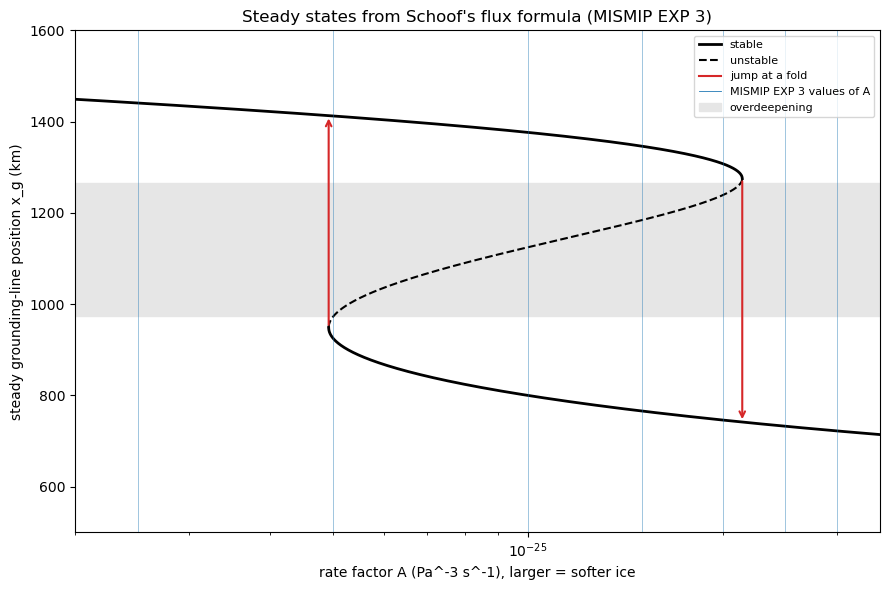

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
first_stable, first_unstable = True, True
start = 0
for i in range(1, len(xg_curve) + 1):
    if i == len(xg_curve) or stable[i] != stable[start]:
        seg = slice(start, i)
        if stable[start]:
            ax.plot(a_curve_si[seg], xg_curve[seg] / 1e3, color="k", lw=2, label="stable" if first_stable else None)
            first_stable = False
        else:
            ax.plot(a_curve_si[seg], xg_curve[seg] / 1e3, color="k", lw=1.5, ls="--", label="unstable" if first_unstable else None)
            first_unstable = False
        start = i
for af, xf, landing in jumps:
    ax.annotate("", xy=(af, landing / 1e3), xytext=(af, xf / 1e3), arrowprops=dict(arrowstyle="->", color="tab:red", lw=1.5))
ax.plot([], [], color="tab:red", label="jump at a fold")
for a_mismip in sorted(set(A_TABLE_SI)):
    ax.axvline(a_mismip, color="tab:blue", lw=0.6, alpha=0.5)
ax.plot([], [], color="tab:blue", lw=0.6, label="MISMIP EXP 3 values of A")
ax.axhspan(x_od1 / 1e3, x_od2 / 1e3, color="0.9", label="overdeepening")
ax.set_xscale("log")
ax.set_xlim(2e-26, 3.5e-25)
ax.set_ylim(500, 1600)
ax.set_xlabel("rate factor A (Pa^-3 s^-1), larger = softer ice")
ax.set_ylabel("steady grounding-line position x_g (km)")
ax.set_title("Steady states from Schoof's flux formula (MISMIP EXP 3)")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "01_steady_states_vs_A.png"), dpi=150)
plt.show()

For step 4 I want to know what Schoof's theory predicts for each MISMIP value of A: one stable state outside the loop, two inside it. I list the stable states and save the curve and the folds to `data/`.

In [9]:
for a_si in sorted(set(A_TABLE_SI), reverse=True):
    states = steady_positions(a_per_year(a_si))
    stable_states = [xg for xg in states if schoof_flux_slope(xg, a_per_year(a_si)) > ACCUMULATION]
    print(f"A = {a_si:.1e}: stable steady states at {', '.join(f'{xg / 1e3:.1f}' for xg in stable_states)} km"
          f"{'  (inside the loop)' if fold_a[0] < a_si < fold_a[1] else ''}")

with open(os.path.join(DATA_DIR, "schoof_steady_states.csv"), "w") as f:
    f.write("x_g_km,A_Pa-3_s-1,stable\n")
    for xg, a_si, st in zip(xg_curve[::10], a_curve_si[::10], stable[::10]):     # every 1 km
        f.write(f"{xg / 1e3:.1f},{a_si:.6e},{int(st)}\n")
with open(os.path.join(DATA_DIR, "schoof_fold_points.csv"), "w") as f:
    f.write("fold,x_g_km,A_Pa-3_s-1,jump_to_km\n")
    for k, (af, xf, landing) in enumerate(jumps):
        f.write(f"{k + 1},{xf / 1e3:.2f},{af:.6e},{landing / 1e3:.2f}\n")
print("saved data/schoof_steady_states.csv and data/schoof_fold_points.csv")

A = 3.0e-25: stable steady states at 721.9 km
A = 2.5e-25: stable steady states at 732.1 km
A = 2.0e-25: stable steady states at 745.7, 1307.8 km  (inside the loop)
A = 1.5e-25: stable steady states at 765.5, 1346.1 km  (inside the loop)
A = 1.0e-25: stable steady states at 799.8, 1376.3 km  (inside the loop)
A = 5.0e-26: stable steady states at 926.1, 1412.4 km  (inside the loop)
A = 2.5e-26: stable steady states at 1440.7 km
saved data/schoof_steady_states.csv and data/schoof_fold_points.csv


## Where to put the calving front

The time-dependent model (steps 2 to 4) needs a fixed calving front beyond every grounding line it may reach. MISMIP fixes the front but the part of the paper I could read does not give its position for experiment 3. The farthest steady grounding line in the MISMIP range is the one for the smallest A. In 1D the length of the floating shelf has no effect on the grounding line (there is no buttressing), so I only need some room beyond it.

In [10]:
x_far = max(steady_positions(a_per_year(min(A_TABLE_SI))))
X_CALVING = 1600e3
print(f"farthest steady grounding line (A = {min(A_TABLE_SI):.1e}): {x_far / 1e3:.1f} km")
print(f"I choose the calving front at {X_CALVING / 1e3:.0f} km, {(X_CALVING - x_far) / 1e3:.0f} km beyond it "
      f"(bed there {bed(X_CALVING):.0f} m)")

farthest steady grounding line (A = 2.5e-26): 1440.7 km
I choose the calving front at 1600 km, 159 km beyond it (bed there -2147 m)
